# Centered vs. non-centered parameterizations: basic logic

When you fit a hierarchical model in HSSM you implicitly choose between two parameterizations of the group-specific (random) effects. They are statistically equivalent, but **the node names in the underlying PyMC graph differ**, and that difference interacts with the way you specify priors. Misalignment between the two leads to a subtle footgun: a prior you supplied can be silently dropped, leaving a *disconnected* free RV in the graph.

This tutorial walks through:

1. The two parameterizations and the equations behind them.
2. How HSSM/bambi name the PyMC nodes in each case.
3. The disconnected-node footgun, the warning HSSM now emits, and two ways to fix it.

## 1. The two parameterizations

For a group-specific intercept $u_g$ with group-level mean $\mu$ and group-level scale $\sigma$:

**Centered (`noncentered=False`)** — sample the group effect directly:

$$u_g \sim \mathcal{N}(\mu, \sigma)$$

**Non-centered (`noncentered=True`, the bambi default)** — sample a standard-normal offset and rescale:

$$z_g \sim \mathcal{N}(0, 1), \qquad u_g = z_g \cdot \sigma$$

Both produce the same prior distribution on $u_g$ when $\mu = 0$. The non-centered form usually samples better because it decouples $u_g$ from $\sigma$ in the geometry of the posterior. **But notice that the non-centered form does not use $\mu$ at all.** That is the source of the footgun we will see below: a `mu` hyperprior you supply on the group term is silently ignored under non-centered.

## 2. Setup

In [1]:
import logging
import os
import shutil
import warnings

# NOTE: The block below is a niche workaround that most users will not need.
# It only matters on macOS when the notebook kernel was launched from a
# non-terminal context (some IDE integrations, GUI launchers) so that
# `/opt/homebrew/bin` is missing from PATH. In that situation
# `pm.model_to_graphviz` raises `ExecutableNotFound: PosixPath('dot')` even
# though Graphviz is installed. We prepend the most common locations only if
# `dot` is not already on PATH, so this is a no-op for everyone else.
if shutil.which("dot") is None:
    for _candidate in ("/opt/homebrew/bin", "/usr/local/bin", "/opt/conda/bin"):
        if os.path.isfile(os.path.join(_candidate, "dot")):
            os.environ["PATH"] = _candidate + os.pathsep + os.environ["PATH"]
            break

import pymc as pm

import hssm

warnings.filterwarnings("ignore")

# Show HSSM warnings inline so we can see the footgun message later.
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
logging.getLogger("hssm").setLevel(logging.WARNING)

cav_data = hssm.load_data("cavanagh_theta")
cav_data.head()

,participant_id,stim,rt,response,theta,dbs,conf
0,0,LL,1.21,1.0,0.656275,1,HC
1,0,WL,1.63,1.0,-0.327889,1,LC
2,0,WW,1.03,1.0,-0.480285,1,HC
3,0,WL,2.77,1.0,1.927427,1,LC
4,0,WW,1.14,-1.0,-0.213236,1,HC


## 3. A centered model

We fit a DDM where the drift rate `v` has a participant-level intercept. We pass `noncentered=False` so bambi builds the term as `1|participant_id ~ Normal(mu, sigma)`.

In [2]:
model_centered = hssm.HSSM(
    data=cav_data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + (1|participant_id)",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.0, "sigma": 1.5},
                "1|participant_id": {
                    "name": "Normal",
                    "mu": 0.0,
                    "sigma": {"name": "HalfNormal", "sigma": 0.5},
                },
            },
        }
    ],
    p_outlier=0.0,
    noncentered=False,
)

[rv.name for rv in model_centered.pymc_model.free_RVs]

['t',
 'z',
 'a',
 'v_Intercept',
 'v_1|participant_id_sigma',
 'v_1|participant_id']

Under the centered parameterization the group-specific term shows up as a single free RV named `v_1|participant_id`, plus its hyperprior `v_1|participant_id_sigma`. We can confirm this visually with the PyMC graph:

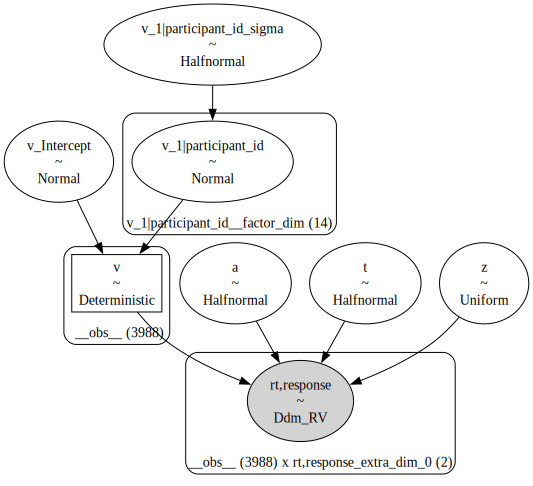

In [3]:
model_centered.graph()

## 4. A non-centered model

Same prior dictionary, but `noncentered=True` (which is also the default if you do not pass the kwarg).

In [4]:
model_noncentered = hssm.HSSM(
    data=cav_data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + (1|participant_id)",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.0, "sigma": 1.5},
                "1|participant_id": {
                    "name": "Normal",
                    "mu": 0.0,
                    "sigma": {"name": "HalfNormal", "sigma": 0.5},
                },
            },
        }
    ],
    p_outlier=0.0,
    noncentered=True,
)

[rv.name for rv in model_noncentered.pymc_model.free_RVs]

['t',
 'z',
 'a',
 'v_Intercept',
 'v_1|participant_id_sigma',
 'v_1|participant_id_offset']

Now there is a new free RV called `v_1|participant_id_offset` (the standardized $z_g$), and `v_1|participant_id` is a *deterministic* equal to `offset * sigma`. The naming convention has changed.

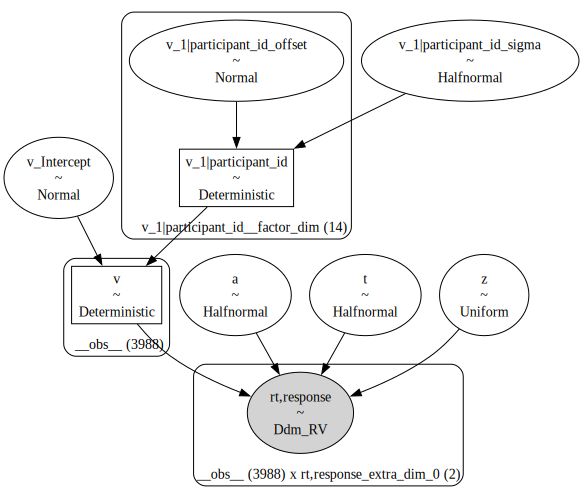

In [5]:
pm.model_to_graphviz(model_noncentered.pymc_model)

## 5. The footgun: a `mu` hyperprior under non-centered

Suppose you write the group prior with a *hyperprior* on the group mean — perfectly natural if you are coming from a centered, fully Bayesian mindset:

```python
"1|participant_id": {
    "name": "Normal",
    "mu": {"name": "Normal", "mu": 0.0, "sigma": 0.5},   # <-- hyperprior on mu
    "sigma": {"name": "HalfNormal", "sigma": 0.5},
}
```

Under `noncentered=True` bambi reparameterizes the term as `offset * sigma` and **never uses `mu`**. The `mu` hyperprior is still created in the PyMC graph (as `v_1|participant_id_mu`), but it is a *disconnected* free RV: it has no path to the observed data. HSSM now warns about this twice — once with a targeted, actionable message, and once with a general "these RVs are not wired in" report.

In [6]:
model_footgun = hssm.HSSM(
    data=cav_data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + (1|participant_id)",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.0, "sigma": 1.5},
                "1|participant_id": {
                    "name": "Normal",
                    "mu": {"name": "Normal", "mu": 0.0, "sigma": 0.5},
                    "sigma": {"name": "HalfNormal", "sigma": 0.5},
                },
            },
        }
    ],
    p_outlier=0.0,
    noncentered=True,
)

User prior for '1|participant_id' on parameter 'v' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'v ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


WARNING hssm: User prior for '1|participant_id' on parameter 'v' supplies a hyperprior on `mu`, but the effective parameterization is non-centered. bambi will reparameterize this term as `offset * sigma` and drop the `mu` hyperprior, leaving it as a disconnected node in the PyMC graph. Either pass `noncentered=False` to `HSSM(...)` so that `mu` is used in the centered Normal, or move the location prior to the common `Intercept` (e.g. use a formula like 'v ~ 1 + (1|participant_id)' and attach the `mu` prior to 'Intercept'). To silence this warning without changing the model, set the `mu` argument to a scalar (e.g. `mu=0`).


The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


WARNING hssm: The PyMC graph contains free random variables that do not influence the likelihood: 'v_1|participant_id_mu'. This typically happens when a hyperprior is supplied for a parameter that the chosen parameterization does not use (e.g. `mu` under `noncentered=True`). These nodes will be sampled but will not affect inference; consider switching the parameterization or adjusting the prior specification.


In [7]:
from hssm.param.parameterization_check import find_disconnected_free_rvs

find_disconnected_free_rvs(model_footgun.pymc_model)

['v_1|participant_id_mu']

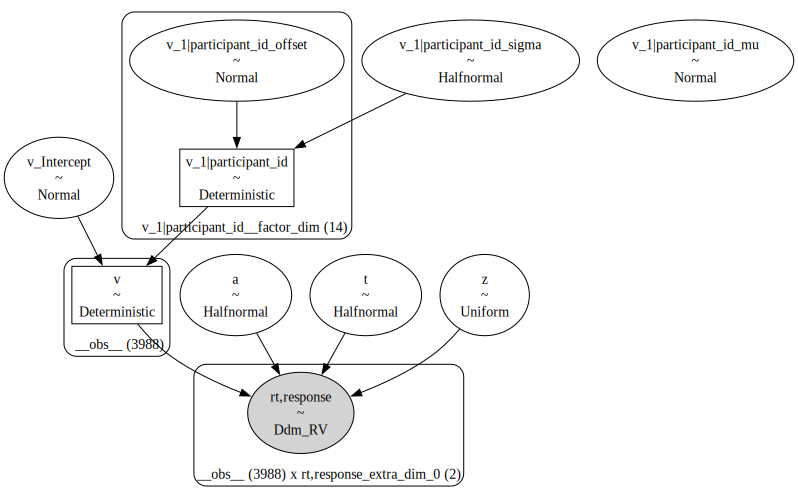

In [8]:
pm.model_to_graphviz(model_footgun.pymc_model)

Notice the floating `v_1|participant_id_mu` node — it has no arrow pointing toward the response. That is the orphan.

### Fix 1 — switch to the centered parameterization

If you really want a hyperprior on the group mean, use `noncentered=False` so that `mu` is wired in.

In [9]:
model_fix_centered = hssm.HSSM(
    data=cav_data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + (1|participant_id)",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.0, "sigma": 1.5},
                "1|participant_id": {
                    "name": "Normal",
                    "mu": {"name": "Normal", "mu": 0.0, "sigma": 0.5},
                    "sigma": {"name": "HalfNormal", "sigma": 0.5},
                },
            },
        }
    ],
    p_outlier=0.0,
    noncentered=False,
)

find_disconnected_free_rvs(model_fix_centered.pymc_model)

[]

In [13]:
model_fix_centered

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 1.5)
        v_1|participant_id ~ Normal(mu: Normal(mu: 0.0, sigma: 0.5), sigma: HalfNormal(sigma: 0.5))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

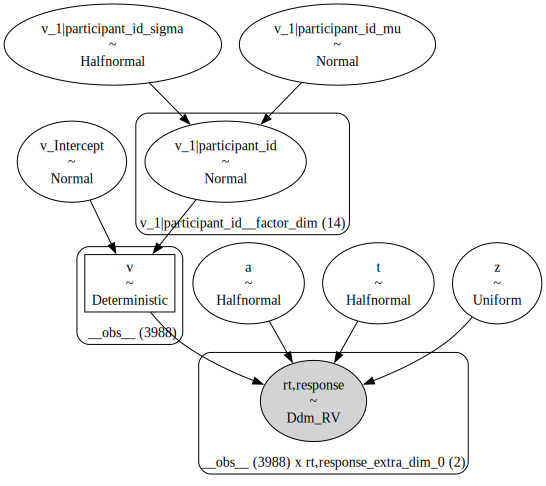

In [11]:
model_fix_centered.graph()

> **Note — Fix 1 trades one problem for another.** Switching to `noncentered=False` removes the disconnected `_mu` node and the graph now looks healthy. But look at the linear predictor for participant `g`:
>
> ```
> v_g = Intercept + u_g
>     = (Intercept + mu_u) + eps_g * sigma_u
> ```
>
> The data only sees the sum `Intercept + mu_u`, so the likelihood is invariant under shifting mass between the two. Their joint posterior has a ridge along the anti-diagonal: samples of `v_Intercept` and `v_1|participant_id_mu` become anticorrelated, the ESS of both drops, and only their sum is well-identified. This is the textbook reason hierarchical models conventionally use **mean-zero random effects**.
>
> HSSM detects this layout automatically and emits a second warning: "User prior for `1|participant_id` on parameter `v` has a non-trivial `mu`, and the formula also includes a common `Intercept`..." Fix 2 below is the clean fix — it sets `mu=0` on the group term so the common `Intercept` owns the location and nothing is redundant.

### Fix 2 — move the location prior to the common intercept

If you want to keep the non-centered parameterization (usually a good idea for sampling), express the location of the group mean through the *common* `Intercept` term, which is shared across the model regardless of parameterization.

In [ ]:
model_fix_intercept = hssm.HSSM(
    data=cav_data,
    model="ddm",
    include=[
        {
            "name": "v",
            "formula": "v ~ 1 + (1|participant_id)",
            "prior": {
                # Location goes here, where both parameterizations use it:
                "Intercept": {"name": "Normal", "mu": 0.0, "sigma": 0.5},
                "1|participant_id": {
                    "name": "Normal",
                    "mu": 0.0,  # scalar, not a hyperprior
                    "sigma": {"name": "HalfNormal", "sigma": 0.5},
                },
            },
        }
    ],
    p_outlier=0.0,
    noncentered=True,
)

find_disconnected_free_rvs(model_fix_intercept.pymc_model)

[]

In [14]:
model_fix_intercept

Hierarchical Sequential Sampling Model
Model: ddm

Response variable: rt,response
Likelihood: analytical
Observations: 3988

Parameters:

v:
    Formula: v ~ 1 + (1|participant_id)
    Priors:
        v_Intercept ~ Normal(mu: 0.0, sigma: 0.5)
        v_1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.5))
    Link: identity
    Explicit bounds: (-inf, inf)

a:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

z:
    Prior: Uniform(lower: 0.0, upper: 1.0)
    Explicit bounds: (0.0, 1.0)

t:
    Prior: HalfNormal(sigma: 2.0)
    Explicit bounds: (0.0, inf)

## 6. Rule of thumb

* Default to `noncentered=True` for hierarchical models — it usually samples better, and is also bambi's default.
* Under `noncentered=True`, **the location of a group-specific term lives on the common intercept (or other common terms)**, not on the `mu` argument of the group prior. Set `mu=0` on the group term itself.
* **Even under `noncentered=False`, set `mu=0` on the group term whenever the formula has a common `Intercept`.** Letting both carry a free location creates a non-identifiable ridge — the data only sees their sum. The two warnings HSSM emits (disconnected `_mu` under non-centered, and location ridge under either parameterization) are saying the same thing from two different angles: mean-zero random effects, full stop.
* Switch to `noncentered=False` only when you have a specific reason (e.g. you want a hyperprior on the group mean *and* you drop the common intercept so the model stays identifiable).
* When in doubt, plot the PyMC graph with `pm.model_to_graphviz(model.pymc_model)` and look for floating nodes. HSSM also flags them automatically and prints a warning.

## 7. Reference

The warnings come from the `"hssm"` logger. If you want to silence them (not recommended), set its level to `ERROR`:

```python
import logging
logging.getLogger("hssm").setLevel(logging.ERROR)
```

If you want to inspect the graph programmatically, use `hssm.param.parameterization_check.find_disconnected_free_rvs(model.pymc_model)`.

## 6. Rule of thumb

* Default to `noncentered=True` for hierarchical models — it usually samples better, and is also bambi's default.
* Under `noncentered=True`, **the location of a group-specific term lives on the common intercept (or other common terms)**, not on the `mu` argument of the group prior. Set `mu=0` on the group term itself.
* Switch to `noncentered=False` only when you have a specific reason (e.g. you want a hyperprior on the group mean and the geometry of your posterior cooperates).
* When in doubt, plot the PyMC graph with `pm.model_to_graphviz(model.pymc_model)` and look for floating nodes. HSSM also flags them automatically and prints a warning.

## 7. Reference

The warnings come from the `"hssm"` logger. If you want to silence them (not recommended), set its level to `ERROR`:

```python
import logging
logging.getLogger("hssm").setLevel(logging.ERROR)
```

If you want to inspect the graph programmatically, use `hssm.param.parameterization_check.find_disconnected_free_rvs(model.pymc_model)`.